In [46]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
path_to_zip = tf.keras.utils.get_file('animals10.zip', origin='https://www.kaggle.com/api/v1/datasets/download/alessiocorrado99/animals10', extract=True)

In [4]:
import pathlib

In [8]:
path_to_zip

'C:\\Users\\rossb\\.keras\\datasets\\animals10_extracted'

In [35]:
image = cv2.imread("coins-1.jpg")

In [36]:
image.shape

(1500, 2000, 3)

In [37]:
cv2.imshow("image", image)
key = cv2.waitKey(0)
cv2.destroyAllWindows()

In [38]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (25, 25), 1)

In [50]:
circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1, minDist=100,
                           param1=100, param2=40, minRadius=40, maxRadius=300)

In [40]:
cv2.imshow("blur", blur)
key = cv2.waitKey(0)
cv2.destroyAllWindows()

In [41]:
circles

array([[[1186.5,  521.5,  130.6],
        [1134.5, 1050.5,  128.4],
        [ 781.5,  717.5,  122.9],
        [ 502.5,  518.5,  120.6],
        [1027.5,  348.5,  108.6],
        [1251.5, 1273.5,  105.1],
        [1416.5,  598.5,   97.7],
        [1369.5,  338.5,  104.6],
        [1476.5,  792.5,  103.1],
        [ 988.5,  633.5,   96.6],
        [1399.5, 1008.5,  114.2],
        [ 990.5,  846.5,   97.7],
        [ 683.5,  363.5,   98.2],
        [ 863.5, 1120.5,  114.2],
        [ 525.5,  758.5,   97.8],
        [1196.5,  739.5,   94.2],
        [ 684.5,  931.5,   98.7],
        [ 858.5,  508.5,   91.1],
        [ 870.5,  234.5,   92.1]]], dtype=float32)

In [51]:
if circles is not None:
    for c in np.uint16(np.round(circles[0])):
        cv2.circle(image, (c[0], c[1]), c[2], (255,0,0), 10)
        cv2.circle(image, (c[0], c[1]), 2, (0,0,255), 20)
cv2.imshow("Circles", image)
cv2.waitKey()
cv2.destroyAllWindows()

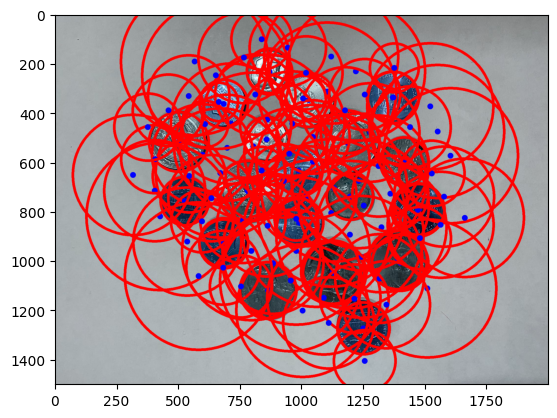

In [52]:
plt.imshow(image)

Parameter is sensitive!

In [54]:
red = image[:, :, 2]

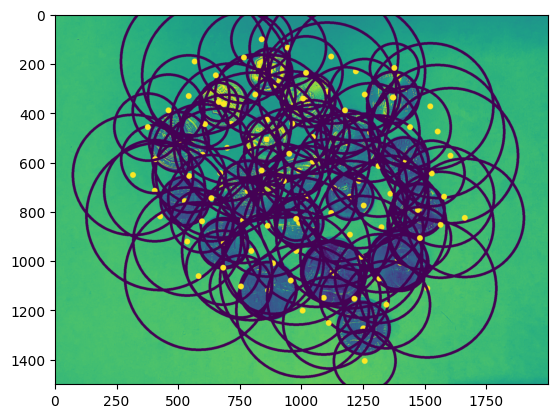

In [55]:
plt.imshow(red)

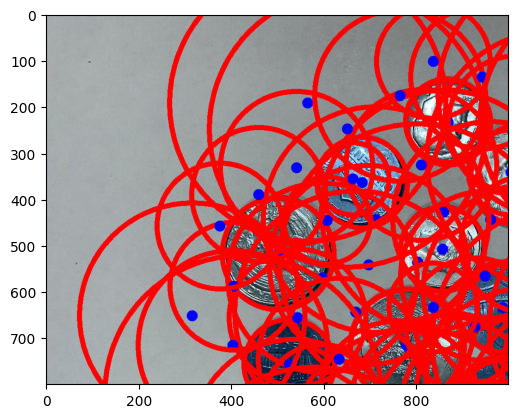

In [57]:
plt.imshow(image[0:800, 0:1000])

In [59]:
reference_path = 'US_One_Cent_Obv.png'

sample = cv2.imread(reference_path)
orb = cv2.ORB_create(nfeatures=500)
kp, ref_desc = orb.detectAndCompute(sample, None)

In [65]:
image = cv2.imread("coins-1.jpg")
bf = cv2.BFMatcher()
kp, desc = orb.detectAndCompute(image, None)
matches = bf.knnMatch(ref_desc, desc, k=2)
count = len([1 for m, n in matches if m.distance < 0.80*n.distance])

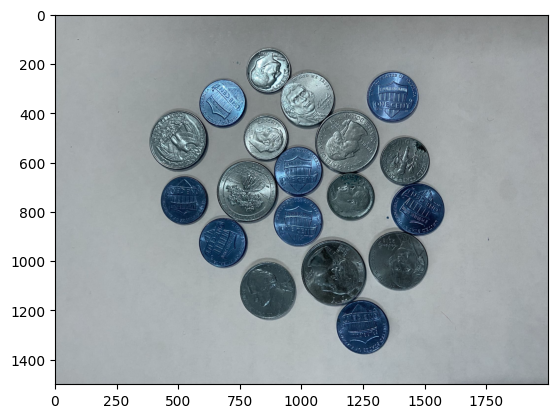

In [66]:
plt.imshow(image)

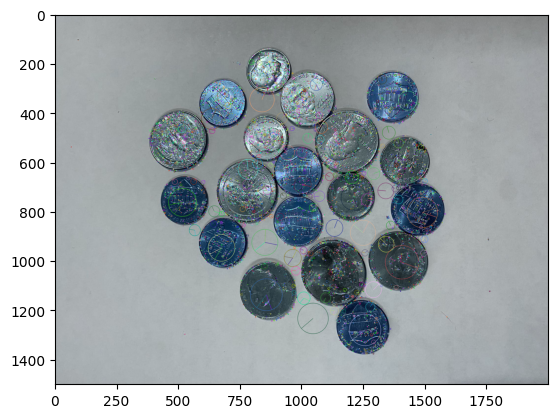

In [76]:
sift = cv2.SIFT_create()
kp = sift.detect(image, None)
plt.imshow(cv2.drawKeypoints(image, kp, image, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS))

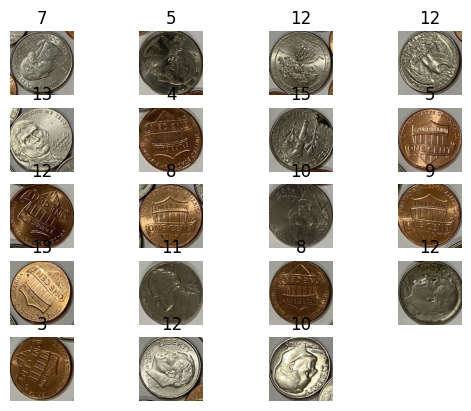

In [74]:
import math

image = cv2.imread("coins-1.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (25,25), 1)
circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1, minDist=100,
                           param1=80, param2=60, minRadius=90, maxRadius=150)

plt.figure(2)
N = len(circles[0])
rows = math.ceil(N / 4)
for i, c in enumerate(np.uint16(np.around(circles[0]))):
    x, y, r = c
    coin = image[y-r:y+r, x-r:x+r]
    coin_gray = cv2.cvtColor(coin, cv2.COLOR_BGR2GRAY)
    kp, desc = orb.detectAndCompute(coin_gray, None)
    matches = bf.knnMatch(ref_desc, desc, k=2)
    count = len([1 for m, n in matches if m.distance < 0.80*n.distance])
    plt.subplot(rows, 4, i+1)
    plt.imshow(cv2.cvtColor(coin, cv2.COLOR_BGR2RGB))
    plt.title(f"{count}")
    plt.axis('off')
plt.show()

In [77]:
idx = 1
for image_path in ["coins-2.jpg", "coins-3.jpg"]:
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (25,25), 1)
    circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT,
                               dp=1, minDist=100,
                               param1=80, param2=60, minRadius=90, maxRadius=150)
 
    for c in np.uint16(np.around(circles[0])):
        x, y, r = c
        cv2.imwrite(f"dataset/{idx}.jpg", img[y-r:y+r, x-r:x+r])
        idx += 1

In [78]:
import glob
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential

images = []
labels = []
for filename in glob.glob("dataset/pos/*"):
    img = cv2.imread(filename)
    img = cv2.resize(img, (256,256))
    images.append(img)
    labels.append(1)
    for _ in range(3):
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        images.append(img)
        labels.append(1)
for filename in glob.glob("dataset/neg/*"):
    img = cv2.imread(filename)
    img = cv2.resize(img, (256,256))
    images.append(img)
    labels.append(0)
    for _ in range(3):
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        images.append(img)
        labels.append(0)

images = np.array(images)
labels = np.array(labels)
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.3)

model = Sequential([
    Conv2D(16, (5,5), input_shape=(256,256,3), padding="same", activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(32, (5,5), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (5,5), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(128, (5,5), activation="relu"),
    Flatten(),
    Dense(256, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Training
earlystopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
model.compile(loss="binary_crossentropy", optimizer="adagrad", metrics=["accuracy"])
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=200, batch_size=32, callbacks=[earlystopping])
model.save("penny.h5")

c:\Users\rossb\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 759ms/step - accuracy: 0.6799 - loss: 122.5866 - val_accuracy: 0.8902 - val_loss: 0.2092
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 738ms/step - accuracy: 0.8784 - loss: 0.3423 - val_accuracy: 0.9191 - val_loss: 0.1750
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 763ms/step - accuracy: 0.9355 - loss: 0.2211 - val_accuracy: 0.8324 - val_loss: 0.2654
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 767ms/step - accuracy: 0.9330 - loss: 0.2110 - val_accuracy: 0.9538 - val_loss: 0.1375
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 772ms/step - accuracy: 0.9752 - loss: 0.1192 - val_accuracy: 1.0000 - val_loss: 0.0598
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 772ms/step - accuracy: 0.9777 - loss: 0.1114 - val_accuracy: 0.9942 - val_loss: 0.0477
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 794ms/step - accuracy: 0.9801 - loss: 0.0823 - val_accuracy: 0.9942 - val_loss: 0.0498
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 798ms/step - accuracy: 0.9926 - loss: 0.0609 

In [79]:
!python -m tf2onnx.convert --keras penny.h5 --output penny.onnx

c:\Users\rossb\AppData\Local\Programs\Python\Python313\python.exe: Error while finding module specification for 'tf2onnx.convert' (ModuleNotFoundError: No module named 'tf2onnx')


In [95]:
model(images[:100])

<tf.Tensor: shape=(100, 1), dtype=float32, numpy=
array([[1.6755874e-04],
       [1.0715185e-03],
       [9.9794006e-01],
       [9.9995172e-01],
       [5.6941528e-04],
       [9.9999386e-01],
       [9.9999779e-01],
       [1.1920084e-06],
       [9.9991149e-01],
       [3.7363127e-03],
       [7.6655269e-08],
       [9.9998134e-01],
       [1.3491914e-05],
       [9.9999189e-01],
       [9.9997294e-01],
       [9.9999082e-01],
       [6.3740602e-03],
       [1.4100301e-07],
       [9.9168450e-01],
       [9.9999988e-01],
       [9.9999261e-01],
       [9.9969101e-01],
       [9.9789202e-01],
       [3.5898567e-05],
       [9.9999535e-01],
       [4.3990898e-05],
       [9.9998140e-01],
       [9.9999940e-01],
       [9.9999839e-01],
       [1.0921576e-03],
       [9.9999982e-01],
       [1.5168065e-03],
       [9.9999970e-01],
       [5.8347023e-06],
       [7.4265437e-05],
       [9.6599199e-03],
       [9.9999321e-01],
       [9.9998510e-01],
       [2.2562983e-02],
       [9.9999

In [ ]:
net = cv2.dnn.readNetFromONNX("penny.onnx")
net.setInput(blob)
output = float(net.forward())

In [ ]:
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "coins-1.jpg"
model_path = "penny.onnx"

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (25,25), 1)
circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT,
                           dp=1, minDist=100,
                           param1=80, param2=60, minRadius=90, maxRadius=150)

plt.figure(2)
N = len(circles[0])
rows = math.ceil(N / 4)
net = cv2.dnn.readNetFromONNX("penny2.onnx")
for i, c in enumerate(np.uint16(np.around(circles[0]))):
    x, y, r = c
    coin = img[y-r:y+r, x-r:x+r]
    coin = cv2.resize(coin, (256,256))
    blob = coin[np.newaxis, ...]
    net.setInput(blob)
    score = float(net.forward())
    plt.subplot(rows, 4, i+1)
    plt.imshow(cv2.cvtColor(coin, cv2.COLOR_BGR2RGB))
    plt.title(f"{score:.2f}")
    plt.axis('off')
plt.show()